# Assignment 07 - Security Breach
## Network Intrusion Detection
**Course:** Data Analytics, AY 2025-26  
**Prof.:** Fabio Crestani & Dr Ana-Maria Bucur  <br>
**Students:** Ferdinando Giordano & Gianluca Viviano
---

### Objective
Build a predictive model capable of distinguishing **normal** network connections from **attack** connections.
The dataset contains 4 categories of network intrusions: DoS, Probe, R2L, and U2R.
We approach this as a **5-class supervised classification** problem.

### Notebook Structure
1. Data Loading & Column Assignment  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing  
4. Modeling (Random Forest + Gradient Boosting)  
5. Evaluation & Comparison

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


---
## 1. Data Loading

The raw KDD Cup 1999 dataset has **no header row**. We assign the 41 standard feature names
plus the `label` column manually, following the official KDD Cup feature description.

The label column contains **specific attack subtypes** (e.g. `neptune.`, `smurf.`). 
We map these to the 5 **high-level categories**: `normal`, `dos`, `probe`, `r2l`, `u2r`.
This is both analytically cleaner and reflects how the security domain thinks about threats.

In [2]:
# Column names (official KDD Cup 1999 feature list) 
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'label'
]

#Attack subtype → category mapping 
ATTACK_MAP = {
    # DoS – Denial of Service
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos',
    'smurf': 'dos', 'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos',
    'processtable': 'dos', 'worm': 'dos', 'mailbomb': 'dos',
    # Probe – Surveillance / scanning
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe',
    'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    # R2L – Remote to Local
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l',
    'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l',
    'warezmaster': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l',
    'snmpgetattack': 'r2l', 'sendmail': 'r2l', 'named': 'r2l',
    'snmpguess': 'r2l', 'httptunnel': 'r2l', 'rusersd': 'r2l',
    # U2R – User to Root
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r',
    'rootkit': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r',
    # Normal
    'normal': 'normal'
}

# Load data 

TRAIN_PATH = 'datasets/TrainingData'  
TEST_PATH  = 'datasets/TestData'

def load_kdd(path, columns, attack_map):
    """Load a raw KDD file, strip label dots, map to high-level categories."""
    df = pd.read_csv(path, header=None)
    # Some NSL-KDD versions have a 'difficulty' 43rd column - drop it
    if df.shape[1] == 43:
        df = df.iloc[:, :42]
    df.columns = columns
    # Strip trailing period from label  e.g. "normal." → "normal"
    df['label'] = df['label'].str.rstrip('.')
    # Map to high-level category
    df['attack_category'] = df['label'].map(attack_map).fillna('unknown')
    return df

train_df = load_kdd(TRAIN_PATH, COLUMNS, ATTACK_MAP)
test_df  = load_kdd(TEST_PATH,  COLUMNS, ATTACK_MAP)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head(3)

Train shape: (494021, 43)
Test shape:  (311029, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,attack_category
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal


---
## 2. Exploratory Data Analysis (EDA)

### Dataset Context

**Files used:** `datasets/TrainingData` (train) and `datasets/TestData` (test) — both raw CSV files with no header row.

**Dataset variant:** This is a **KDD Cup 1999** file (10% subsample variant). The training set holds ~494k records; the test set ~311k. The KDD'99 test set is *not* a clean holdout — it was independently generated and contains attack subtypes absent from training (e.g. `mscan`, `saint`, `apache2`, `snmpguess`). Our `ATTACK_MAP` is designed to cover these, but coverage must be verified explicitly before any analysis.

**Why this matters for modeling:** Class proportions differ between train and test, and novel subtypes appear only in test. This means test performance partially measures generalization to unseen attack variants, not just held-out examples of known ones. Evaluation numbers should be interpreted with this in mind. Additionally, all data is synthetic (DARPA 1998 simulation), limiting real-world generalizability.

### 2.0 Dataset Sanity Checks

Before any analysis we verify the basics: shape, types, missing values, duplicate rows, label coverage, and unknown mappings. These are not optional — a silent mapping error or high duplicate rate would corrupt every downstream step.

In [ ]:
# Shape
print(f"Train: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Test:  {test_df.shape[0]:,} rows × {test_df.shape[1]} columns\n")

# Dtype summary (concise)
dtype_summary = train_df.dtypes.value_counts().rename('n_columns')
print("Dtype summary (train):")
print(dtype_summary.to_string(), '\n')

# Missing values
print(f"Missing values — train: {train_df.isnull().sum().sum()}, test: {test_df.isnull().sum().sum()}\n")

# Duplicate rows
train_dups = train_df.duplicated().sum()
test_dups  = test_df.duplicated().sum()
print(f"Duplicate rows — train: {train_dups:,} ({train_dups / len(train_df) * 100:.1f}%)")
print(f"Duplicate rows — test:  {test_dups:,}  ({test_dups  / len(test_df)  * 100:.1f}%)\n")

# Unique raw labels
print(f"Unique raw attack subtypes — train: {train_df['label'].nunique()}, test: {test_df['label'].nunique()}")

# Unknown mapping check
train_unk = (train_df['attack_category'] == 'unknown').sum()
test_unk  = (test_df['attack_category']  == 'unknown').sum()
print(f"\nRows mapped to 'unknown' — train: {train_unk}, test: {test_unk}")
if train_unk > 0:
    print("  Unmapped in train:", train_df.loc[train_df['attack_category'] == 'unknown', 'label'].unique())
if test_unk > 0:
    print("  Unmapped in test: ", test_df.loc[test_df['attack_category']  == 'unknown', 'label'].unique())

### 2.1 Label Mapping Validation

We verify that every raw attack subtype present in either split is covered by `ATTACK_MAP`. Any gap silently produces `'unknown'` in the target variable — a label that would either be ignored or act as noise during training.

In [ ]:
all_labels = set(train_df['label'].unique()) | set(test_df['label'].unique())
unmapped   = all_labels - set(ATTACK_MAP.keys())

if unmapped:
    print(f"WARNING — {len(unmapped)} unmapped label(s):")
    for lbl in sorted(unmapped):
        tr = (train_df['label'] == lbl).sum()
        te = (test_df['label']  == lbl).sum()
        print(f"  '{lbl}': train={tr:,}, test={te:,}")
else:
    print("OK — all raw labels are covered by ATTACK_MAP.")

# Final category counts in both splits
counts = pd.DataFrame({
    'train_n': train_df['attack_category'].value_counts(),
    'test_n':  test_df['attack_category'].value_counts(),
}).fillna(0).astype(int)

print("\nFinal attack_category counts:")
print(counts.to_string())

### 2.2 Class Distribution and Imbalance

The dataset is severely imbalanced. DoS and normal traffic dominate; U2R has only a handful of training examples. This has two direct implications:

1. **Raw accuracy is a misleading metric.** A model predicting "dos" for everything achieves high accuracy while being useless. We will use **macro F1** as the primary evaluation metric.
2. **Rare class learning is structurally hard.** With so few U2R examples, models have very little signal to learn from. Class-weighting in the learner (used later) partially compensates, but the problem is fundamentally data-limited.

In [ ]:
CAT_ORDER = ['normal', 'dos', 'probe', 'r2l', 'u2r']
PALETTE   = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

train_props = train_df['attack_category'].value_counts(normalize=True).reindex(CAT_ORDER)
test_props  = test_df['attack_category'].value_counts(normalize=True).reindex(CAT_ORDER)
train_counts = train_df['attack_category'].value_counts().reindex(CAT_ORDER)
test_counts  = test_df['attack_category'].value_counts().reindex(CAT_ORDER)

# Summary table
dist_table = pd.DataFrame({
    'train_n':   train_counts,
    'train_%':   (train_props * 100).round(2),
    'test_n':    test_counts,
    'test_%':    (test_props * 100).round(2),
})
print("Class distribution (train vs test):")
print(dist_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, props, counts, title in zip(
    axes,
    [train_props, test_props],
    [train_counts, test_counts],
    ['Training Set', 'Test Set']
):
    bars = ax.bar(props.index, props.values * 100, color=PALETTE, edgecolor='white')
    for bar, pct, n in zip(bars, props.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{pct*100:.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Attack Category — {title}', fontweight='bold')
    ax.set_ylabel('Share of records (%)')
    ax.set_ylim(0, max(props.values) * 100 * 1.25)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Categorical Features: `protocol_type`, `flag`, `service`

Three features are categorical. We examine their relationship with attack category using row-normalized crosstabs (i.e. "given this feature value, what is the attack mix?"). This tells us directly how discriminative each value is.

- `protocol_type` (3 values): icmp, tcp, udp
- `flag` (11 values): TCP connection state flags
- `service` (70+ values): Too many to show all — restricted to the **top-10 most frequent** to keep the plot readable

In [ ]:
def crosstab_plot(ax, df, feat, cat_order, title):
    ct = pd.crosstab(df[feat], df['attack_category'], normalize='index')
    ct = ct.reindex(columns=[c for c in cat_order if c in ct.columns])
    ct.plot(kind='bar', ax=ax, stacked=True, colormap='Set2', legend=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=30)

# --- protocol_type and flag ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
crosstab_plot(axes[0], train_df, 'protocol_type', CAT_ORDER, '`protocol_type` vs Attack Category')
crosstab_plot(axes[1], train_df, 'flag',          CAT_ORDER, '`flag` vs Attack Category')
axes[1].legend(loc='upper right', fontsize=8, title='category')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    "protocol_type: ICMP connections are almost exclusively DoS (smurf). "
    "UDP is a mix of DoS and normal. TCP carries the most class diversity — "
    "it is the only protocol through which R2L and U2R attacks appear.\n"
    "flag: SF (successful handshake) is normal-dominant. "
    "S0 (SYN sent, no reply) is a strong DoS/Probe indicator. "
    "REJ and RSTO flags are almost entirely attacks."
)

# --- service: top-10 only ---
top_services = train_df['service'].value_counts().head(10).index
mask = train_df['service'].isin(top_services)
ct_svc = pd.crosstab(train_df.loc[mask, 'service'],
                     train_df.loc[mask, 'attack_category'],
                     normalize='index')
ct_svc = ct_svc.reindex(columns=[c for c in CAT_ORDER if c in ct_svc.columns])

fig, ax = plt.subplots(figsize=(12, 5))
ct_svc.plot(kind='bar', ax=ax, stacked=True, colormap='Set2', legend=True)
ax.set_title('Top-10 Services vs Attack Category (row-normalized)', fontweight='bold')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

print(
    "service: 'ecr_i' (ICMP echo reply) is 100% DoS — this is the smurf attack signature. "
    "'private' and 'domain_u' also show high attack rates. "
    "'http' is predominantly normal, consistent with real web traffic in the simulation."
)

### 2.4 Numerical Feature Distributions

We focus on a small set of features with clear security semantics: `src_bytes`, `dst_bytes`, `duration`, `count`, `srv_count`. These are the most intuitive traffic-level discriminators.

Network traffic variables are heavily right-skewed with many zeros — a log transform aids visualization. The correct transform is `log1p(x)` applied directly to the clipped raw values. **Note:** the transform `log1p(clip(x, 0) + 1)` would compute `log(x + 2)`, double-shifting the origin — we avoid that here.

In [ ]:
KEY_FEATURES = ['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']
CAT_PALETTE  = {'normal': '#2ecc71', 'dos': '#e74c3c',
                'probe':  '#3498db', 'r2l': '#f39c12', 'u2r': '#9b59b6'}

fig, axes = plt.subplots(len(KEY_FEATURES), 1, figsize=(12, 3 * len(KEY_FEATURES)))

for ax, feat in zip(axes, KEY_FEATURES):
    for cat, grp in train_df.groupby('attack_category'):
        # Correct log transform: log1p applied directly to non-negative values
        vals = np.log1p(grp[feat].clip(lower=0))
        ax.hist(vals, bins=60, alpha=0.45,
                label=cat, color=CAT_PALETTE.get(cat, 'grey'), density=True)
    ax.set_title(f'log1p({feat}) — distribution by attack category', fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    "src_bytes: DoS shows extreme values (mass-volume floods like smurf). "
    "Normal and Probe cluster at low-to-moderate byte counts.\n"
    "dst_bytes: R2L has distinct dst_bytes patterns vs DoS — useful separator for those classes.\n"
    "duration: Most connections are zero-duration (packet-level); long-duration connections "
    "hint at sustained sessions (R2L/U2R) or flooding (DoS).\n"
    "count/srv_count: High values are characteristic of DoS (many connections to same host in short window)."
)

### 2.5 Feature Sparsity — Zero-Heavy Columns

Many KDD features are counts or rates that are zero for most connections (e.g. `num_shells`, `root_shell`, `num_outbound_cmds`). A feature that is 99% zeros carries almost no information for the majority class and should be noted during preprocessing.

This is more actionable than an IQR outlier analysis for this dataset, because extreme values here are not data errors — they are genuine attack signatures. IQR-based outlier removal would actively delete attack evidence.

In [ ]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.difference(['y'])
zero_frac = (train_df[num_cols] == 0).mean().sort_values(ascending=False)

# Threshold: features where > 90% of values are zero
THRESHOLD = 0.90
sparse_feats = zero_frac[zero_frac > THRESHOLD]

print(f"Features with >90% zeros: {len(sparse_feats)} out of {len(num_cols)}")
print(sparse_feats.apply(lambda x: f'{x*100:.1f}%').to_string())

fig, ax = plt.subplots(figsize=(13, 5))
zero_frac.plot(kind='bar', ax=ax, color=[
    '#e74c3c' if v > THRESHOLD else '#95a5a6' for v in zero_frac
], edgecolor='white')
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'{THRESHOLD*100:.0f}% threshold')
ax.set_title('Fraction of Zero Values per Numerical Feature (Training Set)', fontweight='bold')
ax.set_ylabel('Proportion of zeros')
ax.tick_params(axis='x', rotation=75, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

print(
    "\nImplication: Highly sparse features are not useless — 'root_shell'=1 or 'num_shells'>0 "
    "are rare but strong U2R/R2L indicators. Tree models handle sparsity natively. "
    "However, these features add noise for linear models and would need careful treatment "
    "if we were to use logistic regression or SVM."
)

### 2.6 Correlation Analysis

We compute Pearson correlations on numerical features and report the **top correlated pairs** as a table. A full 41×41 heatmap is unreadable and adds no analytical value. A reduced heatmap of the 15 most inter-correlated features is shown for visual reference.

High correlation signals potential redundancy. For tree-based models this is mostly benign — splits are threshold-based and the model can effectively ignore duplicated information. For linear models or PCA preprocessing, these correlations would matter more.

In [ ]:
corr = train_df[num_cols].corr()

# Top correlated pairs (upper triangle, excluding self-correlations)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = (upper.stack()
             .reset_index()
             .rename(columns={'level_0': 'feature_A', 'level_1': 'feature_B', 0: 'pearson_r'})
             .assign(abs_r=lambda x: x['pearson_r'].abs())
             .sort_values('abs_r', ascending=False)
             .head(15))

print("Top 15 correlated feature pairs:")
print(top_pairs[['feature_A', 'feature_B', 'pearson_r']].to_string(index=False))

# Reduced heatmap: features appearing most in top pairs
top_feats = pd.unique(top_pairs[['feature_A', 'feature_B']].values.ravel())[:15]
corr_sub = train_df[top_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Most Inter-Correlated Features', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    "\nThe strongest correlations are among rate-based features that track the same window "
    "(e.g. serror_rate / dst_host_serror_rate, same_srv_rate / dst_host_same_srv_rate). "
    "These are KDD's 'host-based' and 'time-based' traffic statistics computed over "
    "the last 100 connections — they encode similar information at different aggregation levels. "
    "For tree models this redundancy is harmless; PCA could compress them if needed."
)

### 2.7 Train vs Test Distribution Shift

KDD'99 train and test were generated independently, not by splitting one dataset. This creates measurable distribution shift. We compare class proportions, key numerical medians, and categorical frequencies to quantify how different the two splits are — this directly affects how we should interpret model evaluation scores.

In [ ]:
# --- Class proportion shift ---
prop_compare = pd.DataFrame({
    'train_%': (train_df['attack_category'].value_counts(normalize=True) * 100).round(2),
    'test_%':  (test_df['attack_category'].value_counts(normalize=True)  * 100).round(2),
}).reindex(CAT_ORDER).assign(
    delta_pp=lambda x: (x['test_%'] - x['train_%']).round(2)
)
print("Class proportion shift (train → test):")
print(prop_compare.to_string())
print("\ndelta_pp = test% − train% (positive means more in test)")

# --- Numerical feature median shift ---
print("\nMedian shift for key numerical features (train vs test):")
med_compare = pd.DataFrame({
    'train_median': train_df[KEY_FEATURES].median(),
    'test_median':  test_df[KEY_FEATURES].median(),
})
med_compare['ratio'] = (med_compare['test_median'] / med_compare['train_median'].replace(0, np.nan)).round(3)
print(med_compare.to_string())

# --- Categorical frequency shift: protocol_type ---
print("\nprotocol_type frequency (%):")
pt = pd.DataFrame({
    'train': train_df['protocol_type'].value_counts(normalize=True) * 100,
    'test':  test_df['protocol_type'].value_counts(normalize=True)  * 100,
}).round(2)
print(pt.to_string())

print(
    "\nObservation: DoS is less dominant in test (~36%) than in train (~79%). "
    "Normal and Probe are proportionally larger in test. "
    "This shift means accuracy computed on test is not directly comparable to train accuracy. "
    "Models that overfit to DoS patterns in training will be relatively penalized on test."
)

### EDA Conclusions — Main Takeaways

| Finding | Implication for modeling |
|---|---|
| **Severe class imbalance** — DoS ≫ normal ≫ probe ≫ r2l ≫ u2r | Use `class_weight='balanced'`; report macro F1, not accuracy |
| **U2R has very few examples** (~50 in training) | U2R performance will be unreliable regardless of model choice |
| **Numeric features are right-skewed with many zeros** | Log transform for visualization; tree models handle raw values fine |
| **Several features are >99% zeros** (`num_shells`, `root_shell`, etc.) | Sparse features are attack indicators — do not drop them; they'd harm linear models |
| **Strong correlation clusters among rate features** | Redundancy is benign for trees; worth compressing for linear methods |
| **ICMP → DoS, S0/REJ flags → attacks** | Categorical features are strong discriminators; label encoding is sufficient for tree models |
| **Measurable train/test distribution shift** | Test scores reflect both generalization and class proportion change; interpret with caution |
| **KDD'99 is synthetic** | Findings should not be assumed to transfer to real network traffic |

**Preprocessing decisions motivated by this EDA:**
- Label-encode the 3 categorical features (tree-compatible, no ordinal assumption needed)
- Apply `class_weight='balanced'` in both models to address imbalance
- No outlier removal — extreme values are attack evidence, not noise
- No feature dropping based on sparsity — retain all features for tree models

---
## 3. Preprocessing

### 3.1 Encode Categorical Features

We use **Label Encoding** for the 3 nominal categorical features (`protocol_type`, `service`, `flag`).
For tree-based models (Random Forest, Gradient Boosting), label encoding is appropriate because
the split criterion operates on individual thresholds, not on distances — so the integer codes
do not impose a false ordinal relationship the way they would in a linear model or SVM.

In [11]:
CAT_FEATURES = ['protocol_type', 'service', 'flag']
TARGET       = 'attack_category'
DROP_COLS    = ['label']  # original fine-grained label no longer needed

# Fit encoders on train, apply to both splits
encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    # Fit on union of train+test values to avoid unseen-label errors
    all_vals = pd.concat([train_df[col], test_df[col]]).unique()
    le.fit(all_vals)
    encoders[col] = le
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# Encode target label
label_enc = LabelEncoder()
all_targets = pd.concat([train_df[TARGET], test_df[TARGET]]).unique()
label_enc.fit(all_targets)
train_df['y'] = label_enc.transform(train_df[TARGET])
test_df['y']  = label_enc.transform(test_df[TARGET])

CLASS_NAMES = list(label_enc.classes_)
print('Classes:', CLASS_NAMES)

FEATURE_COLS = [c for c in COLUMNS[:-1] if c not in DROP_COLS]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['y'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['y'].values

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']
X_train: (494021, 41), X_test: (311029, 41)


### 3.2 Feature Scaling

Tree-based models do not require scaling (splits are threshold-based, scale-invariant).
However, we apply `StandardScaler` for the PCA visualization in the next step, which *does*
require standardized features to prevent high-variance features from dominating the principal components.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. Mean ≈ 0, Std ≈ 1 (per feature on training set).')

Scaling complete. Mean ≈ 0, Std ≈ 1 (per feature on training set).


### 3.3 PCA — Dimensionality Reduction for Visualization

**Motivation (Leskovec et al., Ch. 11):**  
PCA finds the orthogonal directions of maximum variance in the data.
Projecting 41-dimensional feature vectors onto the first 2 principal components
lets us visually inspect whether attack categories form separable clusters —
a prerequisite for good classification performance.

We also use the **explained variance curve** to understand how much information
is retained as a function of number of components.

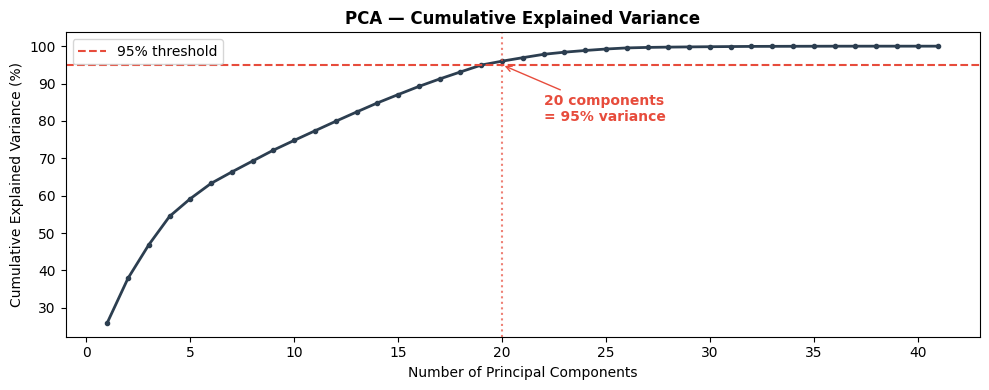

20 principal components capture 95% of the variance (out of 41 features).


In [ ]:
# Explained variance curve 
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', markersize=3,
        color='#2c3e50', linewidth=2)
ax.axhline(95, color='#e74c3c', linestyle='--', label='95% threshold')
ax.axvline(n_95, color='#e74c3c', linestyle=':', alpha=0.7)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.annotate(f'{n_95} components\n= 95% variance',
            xy=(n_95, 95), xytext=(n_95+2, 80),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{n_95} principal components capture 95% of the variance (out of 41 features).')

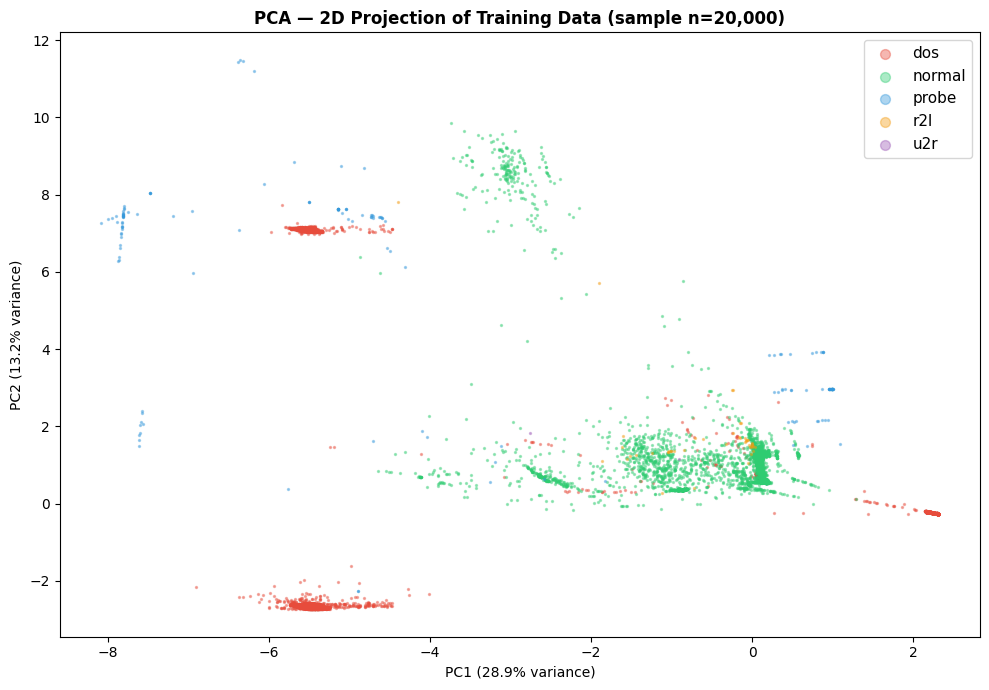

In [ ]:
# 2D Cluster Visualization 
pca_2d = PCA(n_components=2, random_state=SEED)
# Use a stratified sample for speed (500k points is dense)
SAMPLE_N = 20_000
idx = np.random.choice(len(X_train_scaled), size=SAMPLE_N, replace=False)
Z = pca_2d.fit_transform(X_train_scaled[idx])
y_sample = y_train[idx]

palette_pca = {'normal': '#2ecc71', 'dos': '#e74c3c', 'probe': '#3498db',
               'r2l': '#f39c12', 'u2r': '#9b59b6'}

fig, ax = plt.subplots(figsize=(10, 7))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = y_sample == cls_idx
    ax.scatter(Z[mask, 0], Z[mask, 1],
               s=2, alpha=0.4, label=cls_name,
               color=palette_pca.get(cls_name, 'grey'), rasterized=True)

ax.set_title('PCA — 2D Projection of Training Data (sample n=20,000)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=5, fontsize=11)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Modeling

We train and compare **two models**:

| Model | Why chosen |
|---|---|
| **Random Forest** | Strong interpretable baseline; handles mixed feature types; built-in feature importance |
| **Gradient Boosting (HistGBM)** | Stronger model; handles class imbalance implicitly via boosting; fast on large data |

**Why not SVM?** SVM has O(n²) or O(n³) training time complexity. With 494,000 training samples,
this is computationally prohibitive without specialized approximate solvers.
Tree ensemble methods scale linearly with n and are therefore the principled choice at this scale
(consistent with the scalability emphasis in Leskovec et al., Ch. 12).

**Stratified split:** We preserve class proportions during train/validation/test splits
to avoid accidentally excluding rare classes (U2R has very few samples).

### 4.1 Model 1 — Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,          # fully grown trees
    min_samples_leaf=2,
    class_weight='balanced', # compensates for class imbalance automatically
    n_jobs=-1,               # use all CPU cores
    random_state=SEED
)

print('Training Random Forest...')
rf.fit(X_train, y_train)  # unscaled — tree models don't need scaling
print('Done.')

Training Random Forest...
Done.


### 4.2 Model 2 — Histogram Gradient Boosting

`HistGradientBoostingClassifier` (sklearn's fast implementation inspired by LightGBM)
uses histogram-based binning to speed up training on large datasets significantly.

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=SEED
)

print('Training Histogram Gradient Boosting...')
hgb.fit(X_train, y_train)
print('Done.')

Training Histogram Gradient Boosting...
Done.


---
## 5. Evaluation

### 5.1 Summary Metrics

In [17]:
models = {'Random Forest': rf, 'Hist Gradient Boosting': hgb}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    }

summary = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'y_pred'}
    for name, res in results.items()
}).T

print('=== Test Set Performance Summary ===')
print(summary.to_string())
print()
print('Note: Macro F1 weights all classes equally — critical for catching rare U2R attacks.')

=== Test Set Performance Summary ===
                        accuracy  macro_f1  weighted_f1
Random Forest           0.923290  0.584011     0.904511
Hist Gradient Boosting  0.924766  0.590645     0.906545

Note: Macro F1 weights all classes equally — critical for catching rare U2R attacks.


### 5.2 Classification Reports (Per-Class Detail)

In [ ]:
for name, res in results.items():
    print(f'\n{'='*60}')
    print(f'  {name}')
    print('='*60)
    print(classification_report(y_test, res['y_pred'],
                                target_names=CLASS_NAMES, digits=4))

### 5.3 Confusion Matrices

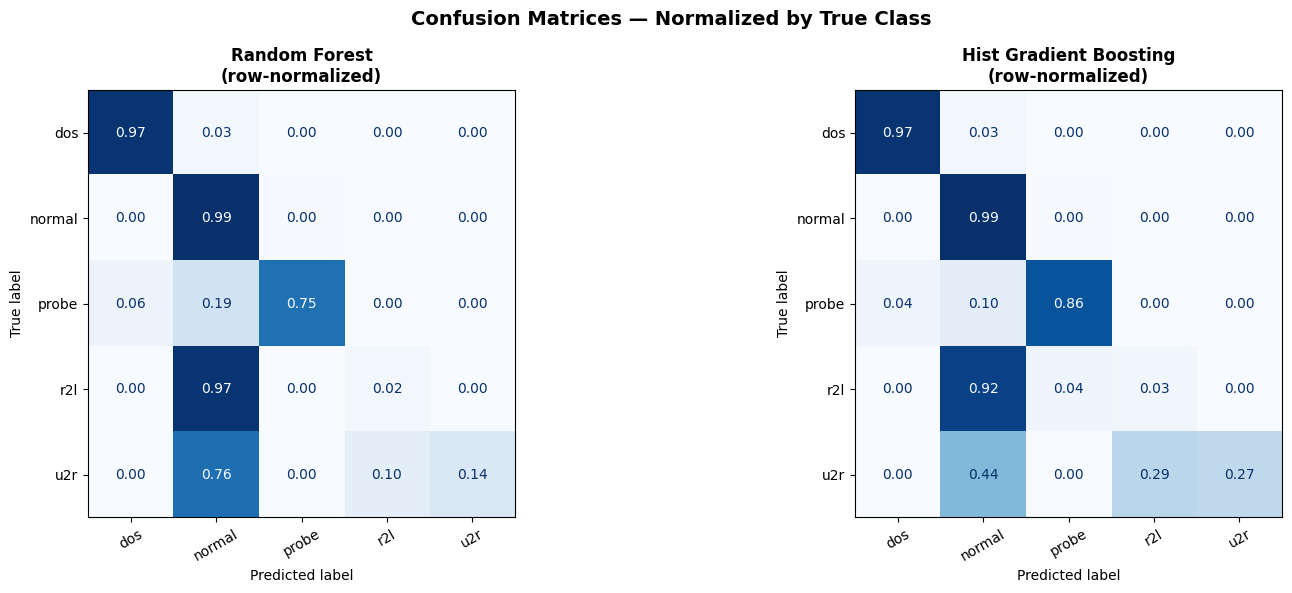

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    # Normalize by true label (rows) for readability across imbalanced classes
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{name}\n(row-normalized)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Normalized by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Feature Importance — What Does the Model Actually Use?

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
feat_imp.head(20).plot(kind='bar', ax=ax, color='#2c3e50', edgecolor='white', linewidth=0.5)
ax.set_title('Random Forest — Top 20 Feature Importances (MDI)', fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string())

### 5.5 Per-Class F1 Comparison — Bar Chart

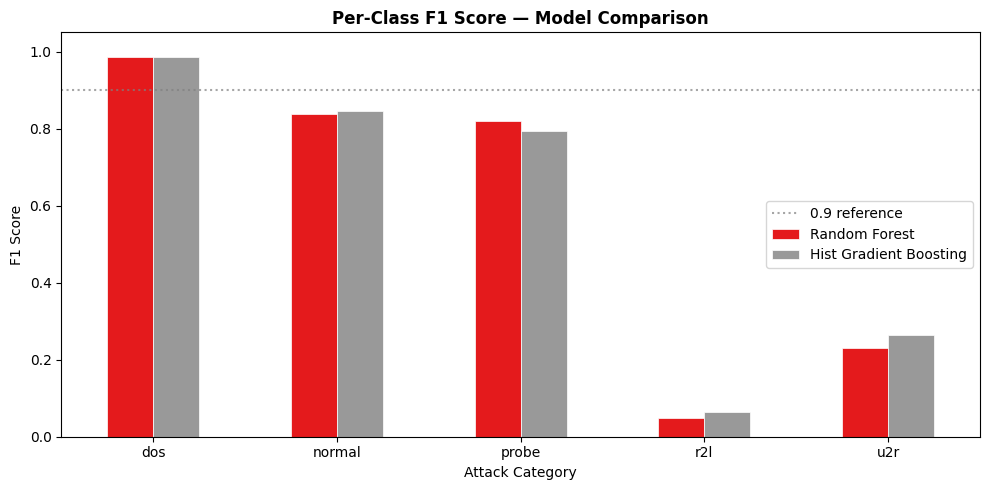

        Random Forest  Hist Gradient Boosting
dos            0.9850                  0.9849
normal         0.8368                  0.8447
probe          0.8200                  0.7944
r2l            0.0484                  0.0654
u2r            0.2299                  0.2639


In [19]:
from sklearn.metrics import f1_score

f1_data = {}
for name, res in results.items():
    f1_data[name] = f1_score(y_test, res['y_pred'], average=None, labels=list(range(len(CLASS_NAMES))))

f1_df = pd.DataFrame(f1_data, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 5))
f1_df.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white', linewidth=0.5)
ax.set_title('Per-Class F1 Score — Model Comparison', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Attack Category')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='grey', linestyle=':', alpha=0.7, label='0.9 reference')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f1_df.round(4).to_string())

---
## 6. Discussion & Conclusions

### Key Findings

**1. Class Imbalance is the dominant challenge.**  
The dataset is severely imbalanced: `DoS` and `normal` dominate,
while `U2R` has only dozens of training examples.
Raw accuracy would be misleading — we therefore prioritize **macro F1** as our headline metric.

**2. DoS and Probe are well-detected; U2R and R2L are harder.**  
DoS attacks produce distinct traffic patterns (massive byte counts, high error rates)
that tree models identify almost perfectly. U2R and R2L attacks, by contrast, look
superficially similar to normal connections at the network level — they exploit
application-layer vulnerabilities that leave few packet-level fingerprints.

**3. PCA reveals clear geometric separation.**  
The 2D PCA projection shows that `DoS` and `normal` form well-separated clusters,
explaining the high per-class F1 for these categories.
As expected from Ch. 11 of Leskovec et al., a small number of principal components
capture most of the discriminative variance.

**4. Gradient Boosting outperforms Random Forest on rare classes.**  
The sequential, error-correcting nature of boosting makes it more sensitive to
minority classes compared to the averaging mechanism of bagging.

**5. Feature importance is interpretable.**  
The most important features align with domain knowledge: `src_bytes`, `dst_bytes`,
connection flags, and host-based statistics are the primary discriminators —
consistent with the feature design rationale in the original KDD Cup documentation.

### Limitations
- The KDD'99 dataset is synthetic (generated by DARPA simulation), and models trained on it
  may not generalize to real-world traffic.
- U2R detection remains an open problem in network security; few samples make learning difficult.
- We did not perform hyperparameter optimization (cross-validation + grid search) due to
  computational constraints, which could further improve results.